In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Titanic

In [2]:
df = pd.read_csv("../datasets/ttn_train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [6]:
df['Age'].value_counts()

Age
24.00    30
22.00    27
18.00    26
28.00    25
19.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64

In [7]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors="ignore")

# Feature Engineering

In [8]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [9]:
# Calculate the family size
def family_size(s, p):
    # s = SibSp, p = Parch, +1 for the passenger
    return s + p + 1

# Applying it to your Titanic DataFrame
df['FamilySize'] = family_size(df['SibSp'], df['Parch'])

# OneHotCoder and Data Imputation

In [10]:
X = df.drop(columns='Survived')
y = df['Survived']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# STEP 1: FIT (Learn the median/mode from the training data)
num_imputer.fit(X_train[['Age']])
cat_imputer.fit(X_train[['Embarked']])

# STEP 2: TRANSFORM (Apply the learned values to both sets)
X_train['Age'] = num_imputer.transform(X_train[['Age']]).ravel()
X_test['Age'] = num_imputer.transform(X_test[['Age']]).ravel()

X_train['Embarked'] = cat_imputer.transform(X_train[['Embarked']]).ravel()
X_test['Embarked'] = cat_imputer.transform(X_test[['Embarked']]).ravel()

In [13]:
# Map Male to 0 and Female to 1 for both sets
X_train['Sex'] = X_train['Sex'].map({'male': 0, 'female': 1})
X_test['Sex'] = X_test['Sex'].map({'male': 0, 'female': 1})

In [14]:
# 1. Initialize the encoder
# handle_unknown='ignore' is a safety net for the test set
# sparse_output=False makes it easier to convert back to a DataFrame
oh_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# 2. FIT and TRANSFORM the training data
embarked_train = oh_encoder.fit_transform(X_train[['Embarked']])

# 3. TRANSFORM the test data (using the categories learned from train)
embarked_test = oh_encoder.transform(X_test[['Embarked']])

# 4. Create DataFrames for the new columns with nice names
cols = oh_encoder.get_feature_names_out(['Embarked'])
df_train_embarked = pd.DataFrame(embarked_train, columns=cols, index=X_train.index)
df_test_embarked = pd.DataFrame(embarked_test, columns=cols, index=X_test.index)

# 5. Concatenate (Glue) them to the main DataFrames and DROP the old text column
X_train = pd.concat([X_train, df_train_embarked], axis=1).drop('Embarked', axis=1)
X_test = pd.concat([X_test, df_test_embarked], axis=1).drop('Embarked', axis=1)

In [15]:
# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. FIT and TRANSFORM the training data
# This calculates the mean and standard deviation of X_train and scales it
X_train_scaled = scaler.fit_transform(X_train)

# 3. TRANSFORM the test data
# We use the mean/std from the training set to avoid data leakage
X_test_scaled = scaler.transform(X_test)

# 4. Convert back to DataFrames to keep your column names (Optional but helpful)
X_train_final = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# 5. Final Check
print(X_train_final.head())

     Pclass       Sex       Age     SibSp     Parch      Fare  FamilySize  \
0 -1.614136 -0.724310  1.253641 -0.470722 -0.479342 -0.078684   -0.554666   
1 -0.400551 -0.724310 -0.477284 -0.470722 -0.479342 -0.377145   -0.554666   
2  0.813034 -0.724310  0.215086 -0.470722 -0.479342 -0.474867   -0.554666   
3  0.813034 -0.724310 -0.246494  0.379923 -0.479342 -0.476230    0.040096   
4  0.813034  1.380624 -1.785093  2.931860  2.048742 -0.025249    3.013909   

   Embarked_C  Embarked_Q  Embarked_S  
0   -0.461462   -0.303355    0.592489  
1   -0.461462   -0.303355    0.592489  
2   -0.461462   -0.303355    0.592489  
3   -0.461462   -0.303355    0.592489  
4   -0.461462   -0.303355    0.592489  


# Deep Learning - ANN

In [16]:
class TitanicModel(nn.Module):
    # Input: features from above
    # Hidden layer (number of neurons)
    # Output feats are survived or not
    def __init__(self, in_features=10, h1=12, h2=6, out_features=2):
        # using fc as fully_connected
        # Linear are the densed connected lines between two groups (eg. inputs and the first rows of hidden layer)
        super().__init__() # instantiate the parent class
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))     # push into hid lay 1
        x = F.relu(self.fc2(x))     # push into hid lay 2
        x = self.out(x)             # output layer

        return x

In [17]:
torch.manual_seed(42)

# Create instance
model = TitanicModel()

In [18]:
X_train_final = torch.FloatTensor(X_train.values)
X_test_final = torch.FloatTensor(X_test.values)
y_train = torch.LongTensor(y_train.values)
y_test = torch.LongTensor(y_test.values)

C:\Users\Admin\AppData\Local\Temp\ipykernel_2244\3044433599.py:3: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y_train = torch.LongTensor(y_train.values)


In [19]:
criterion = nn.CrossEntropyLoss()

# Choose Adam Optimizer, learning rate aka lr (if error doesn't go down after epochs => lower lr)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [20]:
import matplotlib.pyplot as plt

epochs = 100
train_losses = []
test_losses = []

for i in range(epochs):
    # --- TRAINING PHASE ---
    model.train() # Set model to training mode
    y_pred = model.forward(X_train_final)
    loss = criterion(y_pred, y_train)
    train_losses.append(loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # --- VALIDATION/TEST PHASE ---
    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Turn off gradient tracking to save memory
        y_val = model.forward(X_test_final)
        val_loss = criterion(y_val, y_test)
        test_losses.append(val_loss.item())

    if i % 10 == 0:
        print(f'Epoch: {i} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}')

Epoch: 0 | Train Loss: 0.7530 | Val Loss: 0.7195
Epoch: 10 | Train Loss: 0.6113 | Val Loss: 0.5622
Epoch: 20 | Train Loss: 0.5870 | Val Loss: 0.5663
Epoch: 30 | Train Loss: 0.5519 | Val Loss: 0.5310
Epoch: 40 | Train Loss: 0.5110 | Val Loss: 0.5034
Epoch: 50 | Train Loss: 0.4737 | Val Loss: 0.4657
Epoch: 60 | Train Loss: 0.4562 | Val Loss: 0.4585
Epoch: 70 | Train Loss: 0.4433 | Val Loss: 0.4496
Epoch: 80 | Train Loss: 0.4379 | Val Loss: 0.4486
Epoch: 90 | Train Loss: 0.4341 | Val Loss: 0.4449


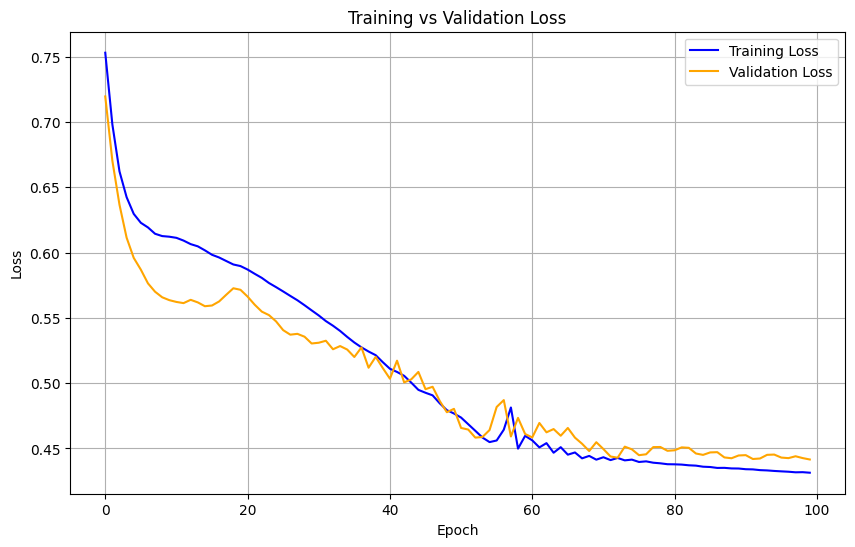

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), train_losses, label='Training Loss', color='blue')
plt.plot(range(epochs), test_losses, label='Validation Loss', color='orange')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Eval

In [22]:
model.eval()
with torch.no_grad():
    # Get raw outputs
    outputs = model(X_test_final)
    # Convert raw numbers to the index of the highest value (0 or 1)
    _, predicted = torch.max(outputs, 1)
    
    # Compare with actual labels
    correct = (predicted == y_test).sum().item()
    total = y_test.size(0)
    accuracy = (correct / total) * 100

print(f'Final Accuracy on Test Set: {accuracy:.2f}%')

Final Accuracy on Test Set: 80.45%


In [23]:
# SINGLE PREDICTION
new_passenger = pd.DataFrame([{
    'Pclass': 3, 'Sex': 0, 'Age': 22, 'SibSp': 1, 'Parch': 0, 'Fare': 7.25, 
    'FamilySize': 2, 'Embarked_C': 0, 'Embarked_Q': 0, 'Embarked_S': 1
}])
new_scaled = torch.tensor(scaler.transform(new_passenger)).float()
with torch.no_grad():
    pred_raw = model(new_scaled)
    prob = F.softmax(pred_raw, dim=1)
    status = "Survived" if torch.argmax(prob) == 1 else "Died"
    print(f"Prediction: {status} ({prob.max().item()*100:.2f}% confidence)")

Prediction: Survived (57.49% confidence)


In [24]:
torch.save(model.state_dict(), "hello_titanic.pt")